29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tamaño entrenamiento: (60000, 28, 28)
Tamaño prueba: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8242 - loss: 0.5013 - val_accuracy: 0.8496 - val_loss: 0.4267
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8643 - loss: 0.3759 - val_accuracy: 0.8438 - val_loss: 0.4240
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8764 - loss: 0.3374 - val_accuracy: 0.8661 - val_loss: 0.3785
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8845 - loss: 0.3122 - val_accuracy: 0.8670 - val_loss: 0.3723
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8906 - loss: 0.2953 - val_accuracy: 0.8790 - val_loss: 0.3406
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8968 - loss: 0.2804 - val_accuracy: 0.8771 - val_loss: 0.3422
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9003 - loss: 0.2701 - val_accuracy: 0.8797 - val_loss: 0.3464
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9040 - loss: 0.2584 -

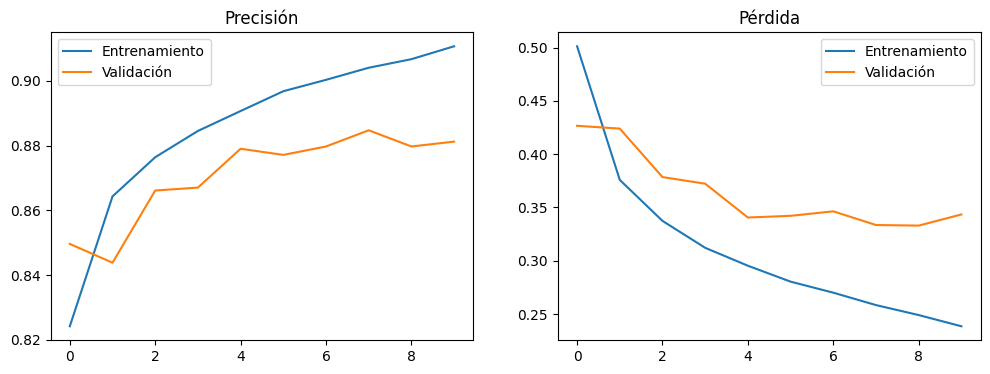

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


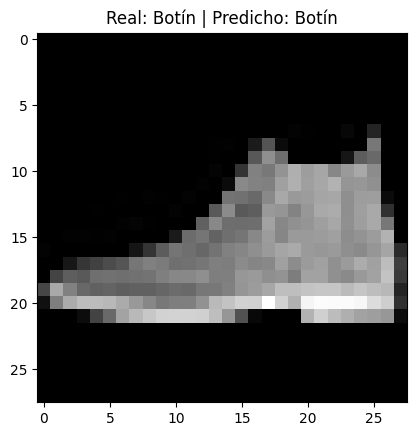

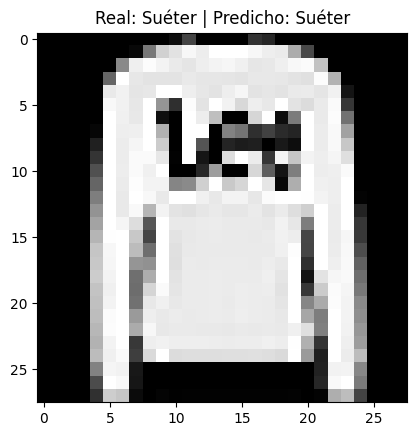

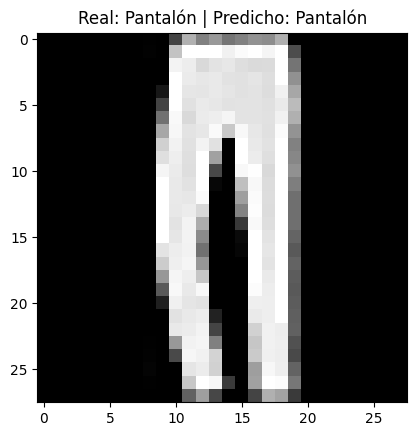

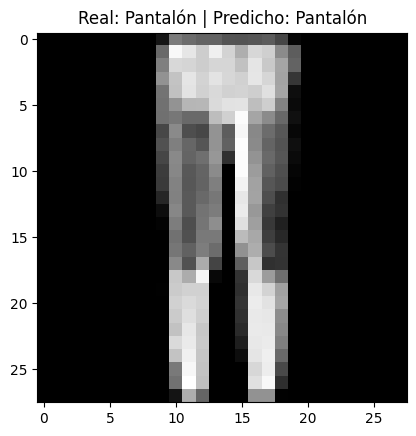

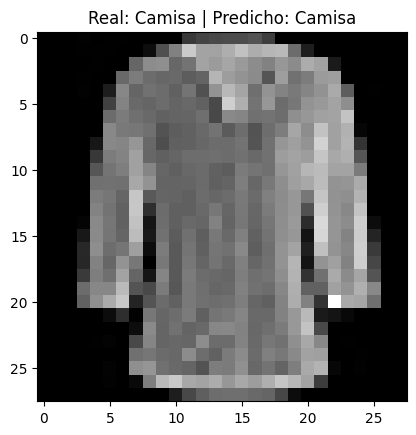

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset Fashion MNIST
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Nombres de las clases (prendas)
nombres_clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

#  Exploración básica
print(f"Tamaño entrenamiento: {X_train.shape}")  # (60000, 28, 28)
print(f"Tamaño prueba: {X_test.shape}")          # (10000, 28, 28)

#  Preprocesamiento: normalizar valores de píxeles (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

#  Construir el modelo (red neuronal secuencial)
modelo = keras.Sequential([

    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 5. Compilar el modelo
modelo.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# 6. Resumen de la arquitectura
modelo.summary()

# 7. Entrenar
historial = modelo.fit(X_train, y_train,
                       epochs=10,
                       validation_data=(X_test, y_test))

# 8. Evaluar en dato
test_loss, test_acc = modelo.evaluate(X_test, y_test, verbose=2)
print(f"\nPrecisión en prueba: {test_acc:.4f}")

# 9. Grafica evolución
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.legend()
plt.show()

# 10. Probar con algunas imágenes del test
predicciones = modelo.predict(X_test[:5])
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Real: {nombres_clases[y_test[i]]} | Predicho: {nombres_clases[np.argmax(predicciones[i])]}")
    plt.show()